# **دانا حسن بافقيه**









#**Import Libraries**

In [ ]:
# For the dataset
import pandas as pd

# For preprocessing
from sklearn.preprocessing import MinMaxScaler

# For Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report, auc, roc_curve, roc_auc_score

# For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


#**Step 1: Data Preprocessing**

##Load the dataset

In [ ]:
# Read the data
Cancer  = pd.read_csv('/content/wdbc[1].data',
                      header = None,      # The data without header
                      delimiter=' *, *',
                      engine='python')

In [ ]:
# Add header to the dataset
Cancer.columns = ['ID','Diagnosis' , 'radius1', 'texture1', 'perimeter1', 'area1',
                    'smoothness1', 'compactness1', 'concavity1',
                    'concave_points1', 'symmetry1', 'fractal_dimension1',
                  'radius2','texture2', 'perimeter2',
                 'area2', 'smoothness2', 'compactness2', 'concavity2',
                 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3',
                 'texture3', 'perimeter3', 'area3', 'smoothness3',
                 'compactness3', 'concavity3', 'concave_points3','symmetry3',
                 'fractal_dimension3']

In [ ]:
# Print the first 5 rows
Cancer.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


##Handeling Missing Value

In [ ]:
# Show information about the data (columns, type, null count)
Cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   Diagnosis           569 non-null    object 
 2   radius1             569 non-null    float64
 3   texture1            569 non-null    float64
 4   perimeter1          569 non-null    float64
 5   area1               569 non-null    float64
 6   smoothness1         569 non-null    float64
 7   compactness1        569 non-null    float64
 8   concavity1          569 non-null    float64
 9   concave_points1     569 non-null    float64
 10  symmetry1           569 non-null    float64
 11  fractal_dimension1  569 non-null    float64
 12  radius2             569 non-null    float64
 13  texture2            569 non-null    float64
 14  perimeter2          569 non-null    float64
 15  area2               569 non-null    float64
 16  smoothne

As we can see, there are no missing value.

##Data Normalization

In [ ]:
# Show statistical summary
Cancer.describe()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


As we can see some columns have a large difference between the minimum and maximum values.  

For example:
- **column 4**: has **min** = 43, **max** = 188
- **column 5**: has **min** = 143, **max** = 2501
- **column 25**: has **min** = 185, **max** = 4254

**so, we need to normalize the data.**

----
Because normalization is applied only to **numerical features**, i split the data into features and target before applying normalization.


In [ ]:
# Split features and target
X = Cancer.drop(['Diagnosis'], axis=1)  # Feature
y = Cancer['Diagnosis']                 # Target

In [ ]:
# Applying normalization to scale features between 0 and 1.
scaler = MinMaxScaler()
normX = scaler.fit_transform(X)

##Split the Dataset

In [ ]:
#Split the dataset into training and testing sets (70% train, 30% test).
X_train, X_test, y_train, y_test = train_test_split(
    normX, y, test_size=0.3, random_state=42
    )

#Step 2: Model Building and Prediction

##Logistic Regression Classifier

In [ ]:
# Build a Logistic Regression Classifier
model1 = LogisticRegression()

# Model training
model1.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predict the classes for the test set
y_pred_LOG = model1.predict(X_test)
print("Predict classes",y_pred_LOG)

# Predict the probabilities for the test set
y_probs_LOG = model1.predict_proba(X_test)[:, 1]
print("Predict probabilities",y_probs_LOG)

Predict classes ['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'M' 'B' 'B'
 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B'
 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M'
 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'M' 'M' 'M' 'M' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'M'
 'B' 'B' 'M' 'B' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M'
 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'M' 'B' 'M' 'B' 'B'
 'M' 'B' 'M' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B']
Predict probabilities [0.18505198 0.96193834 0.82691867 0.06368819 0.02419885 0.99989831
 0.99907542 0.70351256 0.49642407 0.04371394 0.12562162 0.73499192
 0.08642945 0.67357117 0.04817354 0.97674096 0.06025469 0.0083064
 0.0017981  0.9934064  0.27686964 0.08212561 0.9993624  0.0093594
 

##Gaussian NB Classifier

Because all the features are continuous, I use **Gaussian NB**.









In [ ]:
# Build a Gaussian NB Classifier
model2 = GaussianNB()

# Model training
model2.fit(X_train, y_train)

GaussianNB()

In [ ]:
# Predict the classes for the test set
y_pred_GNB = model2.predict(X_test)
print("Predict classes",y_pred_GNB)

# Predict the probabilities for the test set
y_probs_GNB = model2.predict_proba(X_test)[:, 1]
print("Predict probabilities",y_probs_GNB)

Predict classes ['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'B' 'B' 'M' 'B' 'M' 'B' 'M' 'B' 'B'
 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B'
 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M'
 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'M'
 'B' 'B' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'B' 'M'
 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B' 'B' 'M' 'B' 'B' 'M' 'M' 'B' 'M' 'B' 'B'
 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M']
Predict probabilities [9.18682050e-10 1.00000000e+00 1.00000000e+00 6.92805980e-12
 7.39426401e-15 1.00000000e+00 1.00000000e+00 1.00000000e+00
 9.93548523e-01 1.82996461e-15 1.64328637e-14 1.00000000e+00
 2.81223490e-13 1.00000000e+00 3.58547997e-15 1.00000000e+00
 7.34027715e-14 1.76927

#Step 3: Model Evaluation and Visualization

In [ ]:
print("\nLogistic Regression")

# Model Evaluation Metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred_LOG))
print("\nPrecision:", precision_score(y_test, y_pred_LOG,pos_label="M"))
print("\nRecall:", recall_score(y_test, y_pred_LOG, pos_label="M"))
print("\nF1 Score:", f1_score(y_test, y_pred_LOG, pos_label="M"))
print("\nAUC - ROC Score:", roc_auc_score(y_test, y_probs_LOG))

print("\n------------------------------------------------------")

# Classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_LOG))


Logistic Regression

Accuracy: 0.9766081871345029

Precision: 1.0

Recall: 0.9365079365079365

F1 Score: 0.9672131147540983

AUC - ROC Score: 0.9982363315696648

------------------------------------------------------

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98       108
           M       1.00      0.94      0.97        63

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



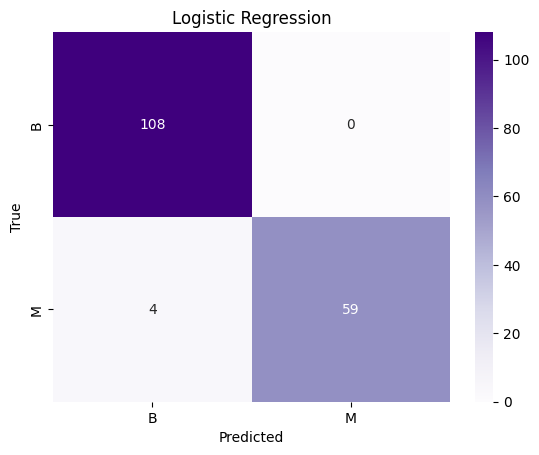

In [ ]:
# Visualize the confusion_matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_LOG, labels=['B','M'])
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',xticklabels=['B', 'M'],yticklabels=['B', 'M'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression')
plt.show()

In [ ]:
print("\nGaussian Naive Bayes")

# Model Evaluation Metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred_GNB))
print("\nPrecision:", precision_score(y_test, y_pred_GNB, pos_label="M"))
print("\nRecall:", recall_score(y_test, y_pred_GNB, pos_label="M"))
print("\nF1 Score:", f1_score(y_test, y_pred_GNB, pos_label="M"))
print("\nAUC - ROC Score:", roc_auc_score(y_test, y_probs_GNB))

print("\n------------------------------------------------------")

# Classification report
print("\nGaussian Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_GNB))


Gaussian Naive Bayes

Accuracy: 0.935672514619883

Precision: 0.9193548387096774

Recall: 0.9047619047619048

F1 Score: 0.912

AUC - ROC Score: 0.9926513815402704

------------------------------------------------------

Gaussian Naive Bayes Classification Report:
              precision    recall  f1-score   support

           B       0.94      0.95      0.95       108
           M       0.92      0.90      0.91        63

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



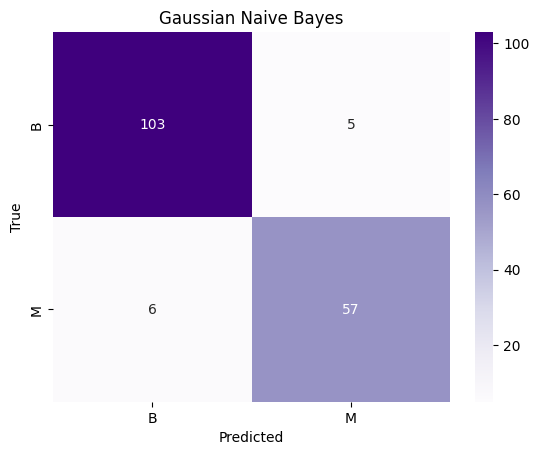

In [ ]:
# Visualize the confusion_matrix for Gaussian Naive Bayes
cm = confusion_matrix(y_test, y_pred_GNB, labels=['B','M'])
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['B', 'M'],yticklabels=['B', 'M'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Gaussian Naive Bayes')
plt.show()

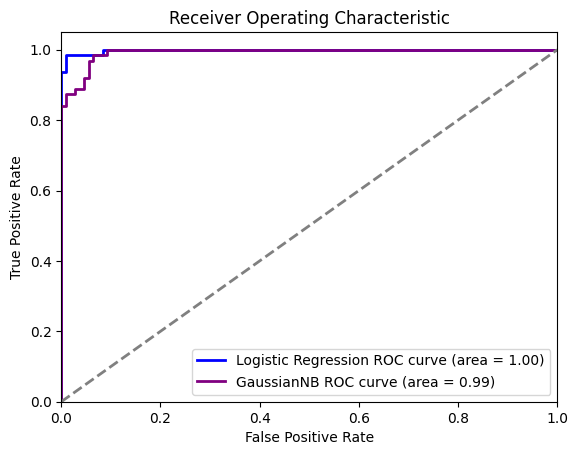

In [ ]:
# Plotting the ROC Curve
fpr_LOG, tpr_LOG, thresholds = roc_curve(y_test, y_probs_LOG, pos_label="M")
roc_auc_LOG = auc(fpr_LOG, tpr_LOG)

fpr_GNB, tpr_GNB, thresholds = roc_curve(y_test, y_probs_GNB, pos_label="M")
roc_auc_GNB = auc(fpr_GNB, tpr_GNB)


plt.figure()
plt.plot(fpr_LOG, tpr_LOG, color='blue', lw=2, label=f'Logistic Regression ROC curve (area = {roc_auc_LOG:.2f})')
plt.plot(fpr_GNB, tpr_GNB, color='purple', lw=2, label=f'GaussianNB ROC curve (area = {roc_auc_GNB:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

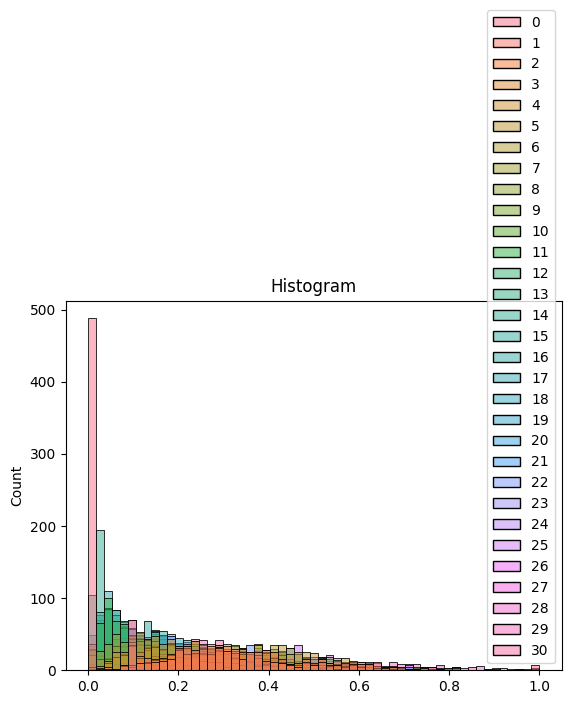

In [ ]:
# check if the feature follow normal distribution
sns.histplot(normX)
plt.title("Histogram")
plt.show()

#**Step 4: Comparative Analysis**

 1. **Compare the performance of Logistic Regression vs. Naive Bayes on each dataset**

The logistic regression model achieved higher accuracy of 0.97, while the Gaussian naïve bayes achieved 0.93, which is still good but lower than logistic regression.
In the precision, logistic regression showed a perfect score 1.0, indicating that the model always predict the positive class with no mistake(FP), while Gaussian achieved 0.9, meaning it predict some of the positive wrong.
Overall, the logistic regression demonstrated better performance and higher score across all the evaluation metrics

2. **Discuss how dataset characteristics (feature types, distributions) influenced results.**

All the features are continuous, which means Gaussian naïve bayes is the best for the data from the naïve bayes family, but it assume the features follow Gaussian distribution (normal), and they actually positive skew. ``(We can see the last figure)``

3. **Explore how preprocessing choices affected model performance.**

I applied normalization on the data because some features had large differences between their values.
When I tested the model without normalization, the logistic regression achieved accuracy that a lower score 0.92 and a precision score of 0.90, while Gaussian naïve bayes achieved an accuracy of 0.63, which not good.
So, normalization had a good effect on the models.

4. **Reflect on which model you would recommend for each dataset and why.**

I recommend logistic regression model because it gives higher performance and fits with the data well, while the GaussianNB assumes a normal distribution which not satisfied in this data.